In [2]:
# Cell 1: Upload file
from google.colab import files
uploaded = files.upload()
# Select train.csv from your computer

Saving train.csv to train.csv


In [3]:
# Cell 2: Load the file
import pandas as pd
df = pd.read_csv('train.csv')  # or whatever the filename is
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts show in the notebook
%matplotlib inline

# Set style for better looking charts
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# Load from web (no upload needed)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Titanic data loaded!")
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Titanic data loaded!
Dataset has 891 rows and 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# See column names
print("Column names:")
print(df.columns.tolist())
print("\n" + "="*50)

# See data types and missing values
print("\nData Info:")
df.info()

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# Count missing values
print("Missing values in each column:")
missing = df.isnull().sum()
print(missing)

# Percentage of missing
print("\nPercentage of missing values:")
print((df.isnull().sum() / len(df)) * 100)

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Percentage of missing values:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [8]:
# Summary for numeric columns
print("Statistical Summary:")
df.describe()

Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# Make a copy to work with
df_clean = df.copy()

# Fill missing Age with median age
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)

# Fill missing Embarked with most common value
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# Drop Cabin column (too many missing values)
df_clean.drop('Cabin', axis=1, inplace=True)

print("Missing values handled!")
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")

Missing values handled!
Remaining missing values: 0


/tmp/ipykernel_1688/3940126089.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
/tmp/ipykernel_1688/3940126089.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [10]:
# Overall survival rate
survival_rate = df_clean['Survived'].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")
print(f"Number survived: {df_clean['Survived'].sum()} out of {len(df_clean)}")

Overall survival rate: 38.4%
Number survived: 342 out of 891


Survival rate by gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


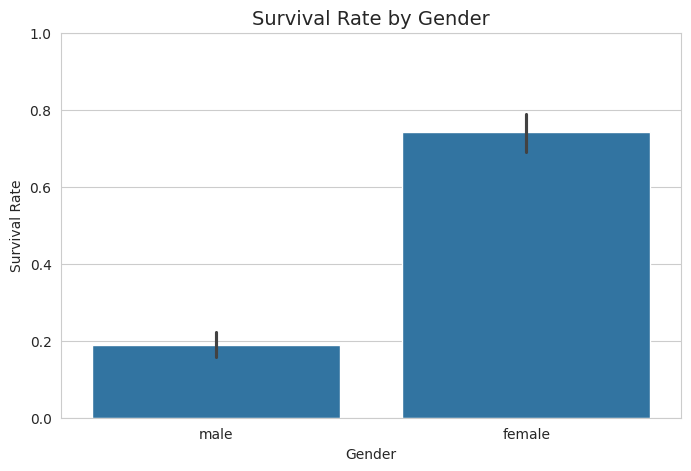

In [11]:
# Survival rate by gender
survival_by_gender = df_clean.groupby('Sex')['Survived'].mean() * 100
print("Survival rate by gender:")
print(survival_by_gender)

# Chart
plt.figure(figsize=(8,5))
sns.barplot(x='Sex', y='Survived', data=df_clean)
plt.title('Survival Rate by Gender', fontsize=14)
plt.ylabel('Survival Rate')
plt.xlabel('Gender')
plt.ylim(0, 1)
plt.show()

Survival rate by passenger class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


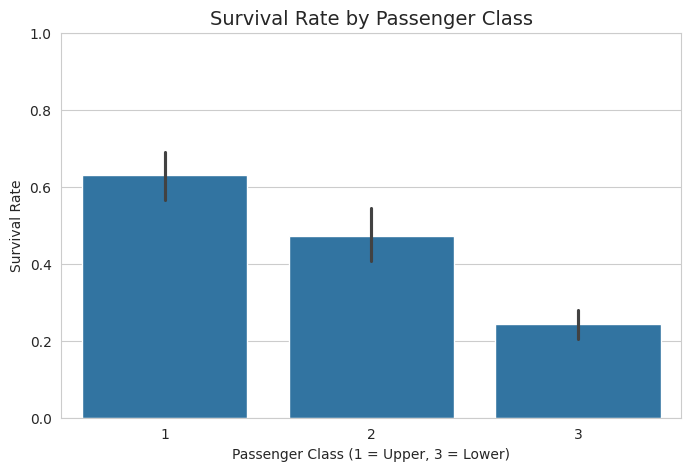

In [12]:
# Survival rate by class
survival_by_class = df_clean.groupby('Pclass')['Survived'].mean() * 100
print("Survival rate by passenger class:")
print(survival_by_class)

# Chart
plt.figure(figsize=(8,5))
sns.barplot(x='Pclass', y='Survived', data=df_clean)
plt.title('Survival Rate by Passenger Class', fontsize=14)
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class (1 = Upper, 3 = Lower)')
plt.ylim(0, 1)
plt.show()

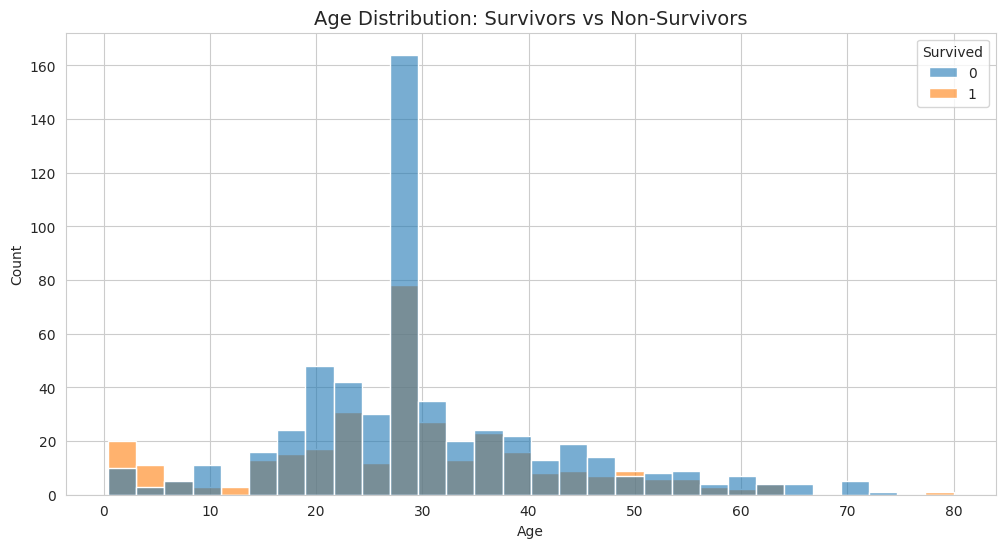

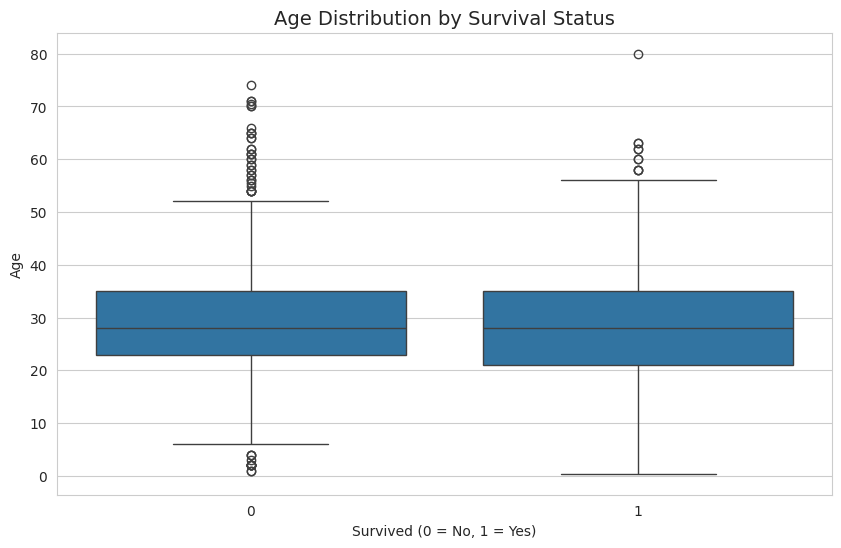

In [13]:
plt.figure(figsize=(12,6))

# Histogram of age by survival
sns.histplot(data=df_clean, x='Age', hue='Survived', bins=30, alpha=0.6)
plt.title('Age Distribution: Survivors vs Non-Survivors', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x='Survived', y='Age', data=df_clean)
plt.title('Age Distribution by Survival Status', fontsize=14)
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

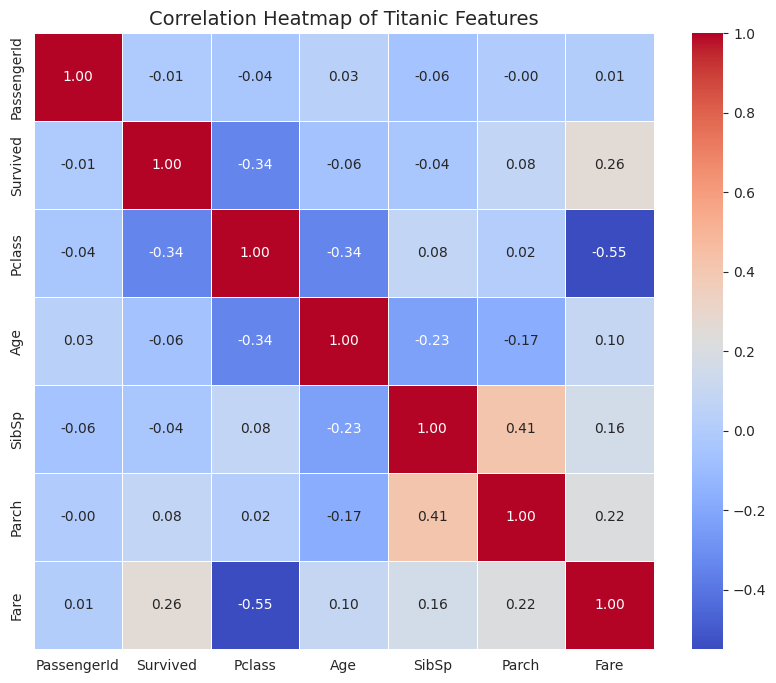

In [14]:
# Select only numeric columns
numeric_cols = df_clean.select_dtypes(include=[np.number])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Titanic Features', fontsize=14)
plt.show()

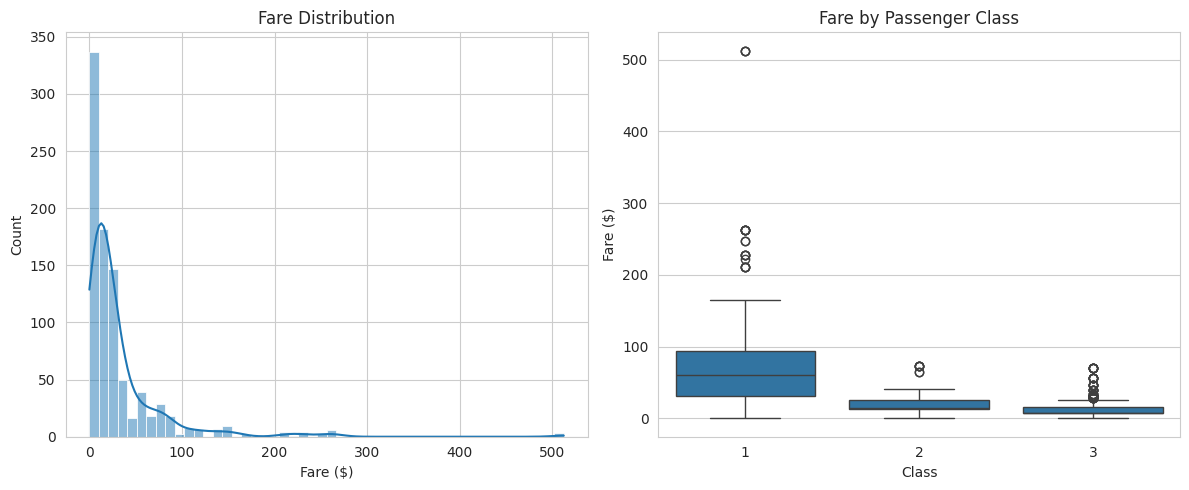

In [15]:
plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df_clean['Fare'], bins=50, kde=True)
plt.title('Fare Distribution')
plt.xlabel('Fare ($)')

# Boxplot by class
plt.subplot(1, 2, 2)
sns.boxplot(x='Pclass', y='Fare', data=df_clean)
plt.title('Fare by Passenger Class')
plt.xlabel('Class')
plt.ylabel('Fare ($)')

plt.tight_layout()
plt.show()

Survival rate by embarkation port:
Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


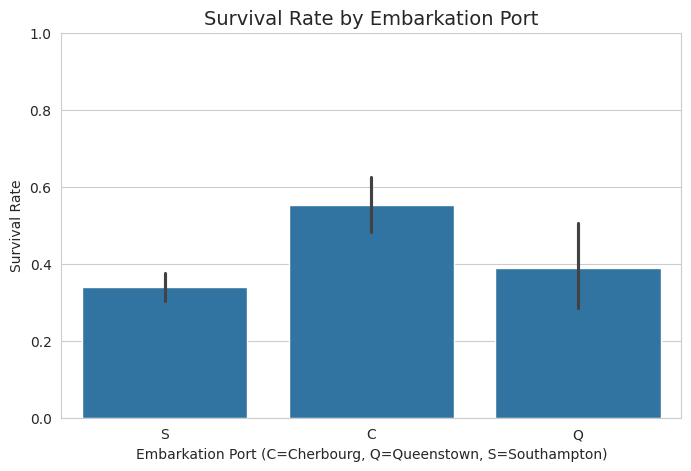

In [16]:
# Survival by embarkation port
embark_survival = df_clean.groupby('Embarked')['Survived'].mean() * 100
print("Survival rate by embarkation port:")
print(embark_survival)

# Chart
plt.figure(figsize=(8,5))
sns.barplot(x='Embarked', y='Survived', data=df_clean)
plt.title('Survival Rate by Embarkation Port', fontsize=14)
plt.xlabel('Embarkation Port (C=Cherbourg, Q=Queenstown, S=Southampton)')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

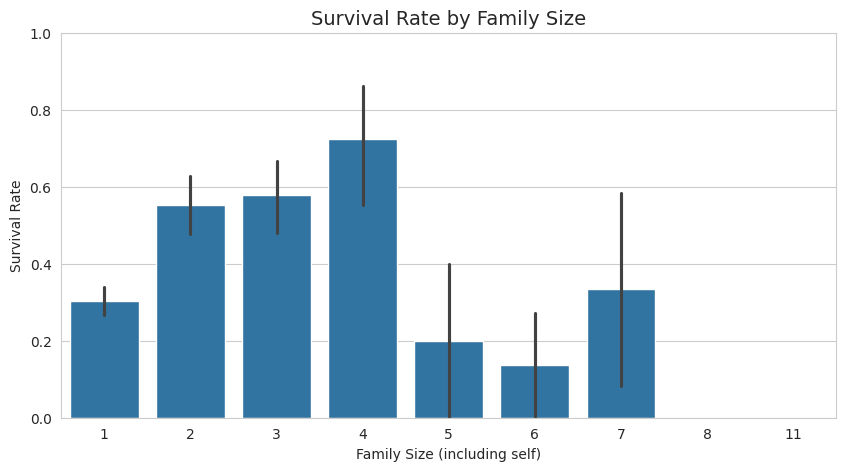

Survival rate by family size:
FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64


In [17]:
# Create family size column
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# Survival by family size
family_survival = df_clean.groupby('FamilySize')['Survived'].mean() * 100

plt.figure(figsize=(10,5))
sns.barplot(x='FamilySize', y='Survived', data=df_clean)
plt.title('Survival Rate by Family Size', fontsize=14)
plt.xlabel('Family Size (including self)')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

print("Survival rate by family size:")
print(family_survival)

In [18]:
print("="*60)
print("TITANIC EDA - KEY FINDINGS SUMMARY")
print("="*60)

print(f"\n1. Overall Survival Rate: {survival_rate:.1f}%")

print(f"\n2. Gender Impact:")
print(f"   - Women survival: {survival_by_gender['female']:.1f}%")
print(f"   - Men survival: {survival_by_gender['male']:.1f}%")

print(f"\n3. Passenger Class Impact:")
print(f"   - 1st Class: {survival_by_class[1]:.1f}%")
print(f"   - 2nd Class: {survival_by_class[2]:.1f}%")
print(f"   - 3rd Class: {survival_by_class[3]:.1f}%")

print("\n4. Missing Data Handled:")
print("   - Age: Filled with median age")
print("   - Embarked: Filled with most common port")
print("   - Cabin: Dropped (too many missing)")

print("\n5. Key Correlation Findings:")
print("   - Pclass and Fare: Strong negative correlation")
print("   - Survived and Pclass: Moderate negative correlation")
print("   - Survived and Sex: Strong correlation (female = higher survival)")

TITANIC EDA - KEY FINDINGS SUMMARY

1. Overall Survival Rate: 38.4%

2. Gender Impact:
   - Women survival: 74.2%
   - Men survival: 18.9%

3. Passenger Class Impact:
   - 1st Class: 63.0%
   - 2nd Class: 47.3%
   - 3rd Class: 24.2%

4. Missing Data Handled:
   - Age: Filled with median age
   - Embarked: Filled with most common port
   - Cabin: Dropped (too many missing)

5. Key Correlation Findings:
   - Pclass and Fare: Strong negative correlation
   - Survived and Pclass: Moderate negative correlation
   - Survived and Sex: Strong correlation (female = higher survival)


In [19]:
# Save cleaned data for future use
df_clean.to_csv('titanic_cleaned.csv', index=False)
print("Cleaned dataset saved as 'titanic_cleaned.csv'")

# Download to your computer
from google.colab import files
files.download('titanic_cleaned.csv')

Cleaned dataset saved as 'titanic_cleaned.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>